# **Telecommunications**
_____

At the CallMeMaybe call center, the most important metric is productivity: the average number of calls received and the wait time per agent. The goal of the project is to identify underperforming agents based on the following KPIs:

- Incoming and outgoing call loss rate
- Average Handle Time (AHT) per customer call
- Number of calls answered

Additionally, other KPIs that will help measure service quality are:

- Agent response time
- Number of times a customer called on the same day

El dataset comprimido `telecom_dataset_us.csv` contiene las siguientes columnas:

- `user_id`: ID de la cuenta de cliente
- `date`: fecha en la que se recuperaron las estadísticas
- `direction`: "dirección" de llamada (`out` para saliente, `in` para entrante)
- `internal`: si la llamada fue interna (entre los operadores de un cliente o clienta)
- `operator_id`: identificador del operador
- `is_missed_call`: si fue una llamada perdida
- `calls_count`: número de llamadas
- `call_duration`: duración de la llamada (sin incluir el tiempo de espera)
- `total_call_duration`: duración de la llamada (incluido el tiempo de espera)

 

El conjunto de datos `telecom_clients_us.csv` tiene las siguientes columnas:

- `user_id`: ID de usuario/a
- `tariff_plan`: tarifa actual de la clientela
- `date_start`: fecha de registro de la clientela

________

In [ ]:
#Library to work 
import pandas as pd 
import numpy as np 
from scipy import stats 
# view data set 
import matplotlib.pyplot as plt
import seaborn as sns 
import statsmodels.stats.api as sms

In [ ]:
# process information
tele_cx = pd.read_csv(r'C:\Users\USUARIO\Desktop\TripleTen\Sprint_15\telecom_clients.csv')
tele_data = pd.read_csv(r'C:\Users\USUARIO\Desktop\TripleTen\Sprint_15\telecom_dataset_new.csv')

### **1. Cleaning Dataset**
Look for missing values, duplicated, datetime columns 


In [ ]:
def explore(x):
    divider = "*_*"
    print("\n {} \n".format((divider*20))) 
#creates a dvider between each method output breaking at each end.
    print("Dataframe Makeup \n") #title for output.
    x.info() 
# Explains what the data and values the data is madeup from.
    print("\n {} \n".format((divider*20))) 
#creates a dvider between each method output breaking at each end
    print("Duplicated:{}\n".format(x.duplicated().sum()))
    
# duplifates row 
    print("Missing values:\n{}\n".format(x.isna().sum()))
    print("\n {} \n".format((divider*20))) 
# count missing values 
    print("Shape of dataframe: {}".format(x.shape))
# Gives the shape of the data.

    return

In [ ]:
# explore data, identify values, duplicates and missing information.
explore(tele_cx)


 *_**_**_**_**_**_**_**_**_**_**_**_**_**_**_**_**_**_**_**_* 

Dataframe Makeup 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB

 *_**_**_**_**_**_**_**_**_**_**_**_**_**_**_**_**_**_**_**_* 

Duplicated:0

Missing values:
user_id        0
tariff_plan    0
date_start     0
dtype: int64


 *_**_**_**_**_**_**_**_**_**_**_**_**_**_**_**_**_**_**_**_* 

Shape of dataframe: (732, 3)


In [ ]:
explore(tele_data)


 *_**_**_**_**_**_**_**_**_**_**_**_**_**_**_**_**_**_**_**_* 

Dataframe Makeup 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB

 *_**_**_**_**_**_**_**_**_**_**_**_**_**_**_**_**_**_**_**_* 

Duplicated:4900

Missing values:
user_id                   0
date                      0
direction                 0
inter

tele_cx:
- tranform to datatime the column date_start
tele_data:
- tranform to datatime the column date
Note: 
- tela_data had missing values like internal and operation_id, althought its means the user does not get and answer on the call 
- tela_data had duplicated values, when they call more that one time. (*deeply verification of duplicated*)

In [ ]:
# transfor to date time 
tele_cx['date_start'] = pd.to_datetime(tele_cx['date_start'])
tele_data['date'] =pd.to_datetime(tele_data['date'])

# Replace missing values to indetify call not attendent 
tele_data['internal'] = tele_data['internal'].fillna('missing');
tele_data['operator_id'] = tele_data['operator_id'].fillna(0);

# looking for duplicates 
# user id can do more than one call on the same day 
# The user and the company made more than one call on the same day
# To ensure delete duplicates, the columns to use are user_id, direction,  date, total_call_duration and keep justo on duplicate
tele_data = tele_data.drop_duplicates(
    subset=['user_id', 'date', 'direction', 'total_call_duration'],
    keep='first'
);
tele_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48469 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype                    
---  ------               --------------  -----                    
 0   user_id              48469 non-null  int64                    
 1   date                 48469 non-null  datetime64[ns, UTC+03:00]
 2   direction            48469 non-null  object                   
 3   internal             48469 non-null  object                   
 4   operator_id          48469 non-null  float64                  
 5   is_missed_call       48469 non-null  bool                     
 6   calls_count          48469 non-null  int64                    
 7   call_duration        48469 non-null  int64                    
 8   total_call_duration  48469 non-null  int64                    
dtypes: bool(1), datetime64[ns, UTC+03:00](1), float64(1), int64(4), object(2)
memory usage: 3.4+ MB


### **2. Exploratory Dataset**

#### 2.1 Histogram: plan acquired A, B, and C 



In [ ]:
# Library for graphy 
title = {'fontsize': 12, 'fontweight': 'bold', 'color':'black'}
subtitle  = {'fontsize': 10, 'fontweight': 'light', 'color': 'grey'}
month_ = ['AUG','SEP','OCT', 'NOV']

Text(0, 0.5, 'Plan C')

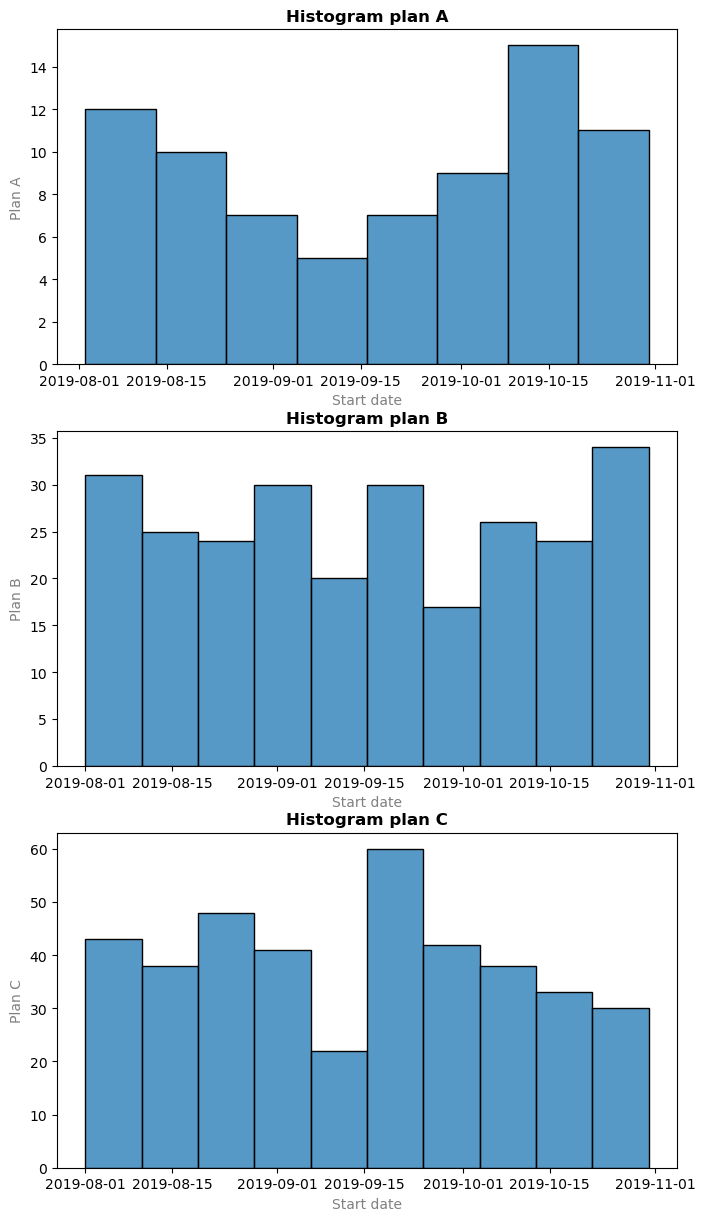

In [ ]:
fig = plt.figure(figsize=[8,20])
gs = fig.add_gridspec(4,1)
#PLAN A
ax1 = fig.add_subplot(gs[0,0])
sns.histplot(
    data=tele_cx.query("tariff_plan == 'A'"),
    x = 'date_start',
    ax = ax1 )
ax1.set_title('Histogram plan A', fontdict = title)
ax1.set_xlabel('Start date', fontdict= subtitle)
ax1.set_ylabel('Plan A', fontdict= subtitle)
#PLAN B
ax2 = fig.add_subplot(gs[1,0])
sns.histplot(
    data=tele_cx.query("tariff_plan == 'B'"),
    x = 'date_start',
    ax = ax2 )
ax2.set_title('Histogram plan B', fontdict = title)
ax2.set_xlabel('Start date', fontdict= subtitle)
ax2.set_ylabel('Plan B', fontdict= subtitle)

#PLAN C
ax3 = fig.add_subplot(gs[2,0])
sns.histplot(
    data=tele_cx.query("tariff_plan == 'C'"),
    x = 'date_start',
    ax = ax3 )
ax3.set_title('Histogram plan C', fontdict = title)
ax3.set_xlabel('Start date', fontdict= subtitle)
ax3.set_ylabel('Plan C', fontdict= subtitle)



#### 2.2 explore service:  
- Number of customer did not get a service 
- Number of customer that get the service just whit the first call 
- Number of customer that call more that one time to get the service on the same day


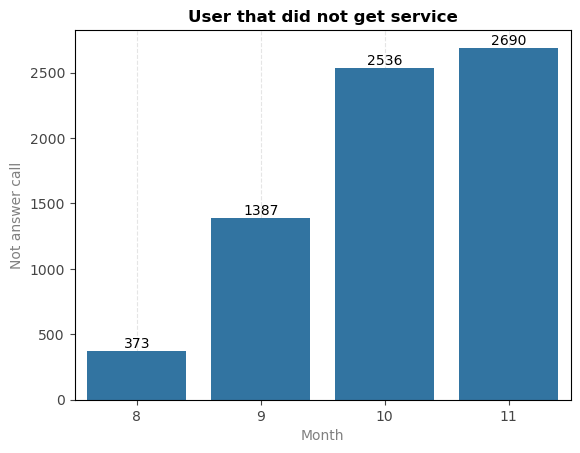

In [ ]:
### Customer that no get service ###

# First, we are going to split the month and the day of the interaction to analyze the service 
tele_data['month'] = tele_data['date'].dt.month
tele_data['day'] = tele_data['date'].dt.day
# Look for the number of customer that no get a service on the same day 
not_service = tele_data.query('operator_id == 0 and call_duration == 0')
not_service = not_service.groupby(['user_id','month','day']).agg( call_not_answear = ('call_duration','count')).reset_index()
## Graphy 
plt.Figure(figsize=[5,7])
ax = sns.countplot(data =not_service, x='month' )
2
ax.tick_params(axis='both', labelsize=10, colors='#444444')
ax.xaxis.grid(True, linestyle='--', alpha=0.5, color='#cccccc')
ax.set_axisbelow(True)
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}',
                (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom')
plt.show()


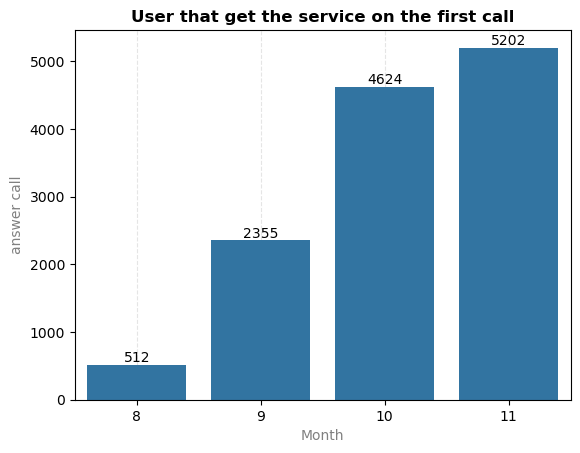

In [ ]:
### costumer that get the service just whit the first time ###
service_first_call = tele_data.query(
    'calls_count == 1'
    ).groupby(
        ['user_id','month','day']
        ).agg( 
            call_answear_first = ('calls_count','sum')
            ).reset_index()
service_first_call_ = service_first_call.groupby('month').agg({'call_answear_first':'sum'}).reset_index()
plt.Figure(figsize=[5,7])
ax1 = sns.barplot(data =service_first_call_, x='month', y='call_answear_first', errorbar=None)
ax1.set_title('User that get the service on the first call', fontdict = title)
ax1.set_ylabel('answer call', fontdict = subtitle)
ax1.set_xlabel('Month', fontdict = subtitle )
ax1.tick_params(axis='both', labelsize=10, colors='#444444')
ax1.xaxis.grid(True, linestyle='--', alpha=0.5, color='#cccccc')
ax1.set_axisbelow(True)
for p in ax1.patches:
    height = p.get_height()
    ax1.annotate(f'{int(height)}',
                (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom')
plt.show()


#### 2.3 Number of outbound and inbound calls monthly that was attendent.
Outbound call: call made for the company to customer.
Inbound: call made for the customer to the company.

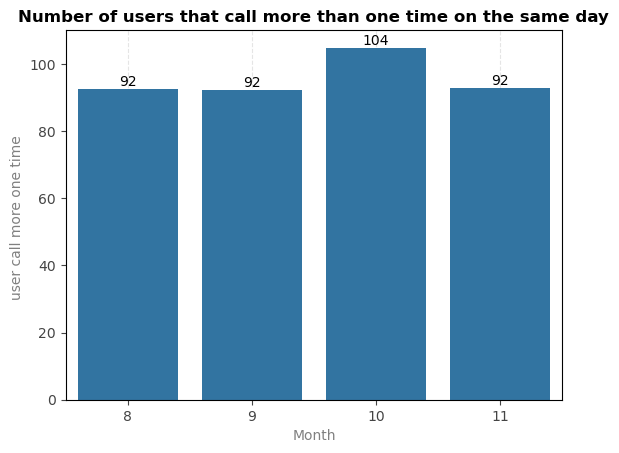

In [ ]:
### customer that call more that one time ### 
more_one_call = tele_data.query(
    'calls_count >= 2'
    ).groupby(
        ['user_id','month','day']
        ).agg( 
            more_one_call = ('calls_count','sum')
            ).reset_index()
plt.Figure(figsize=[5,7])
ax2 = sns.barplot(data =more_one_call, x='month', y='more_one_call', errorbar= None)
ax2.set_title('Number of users that call more than one time on the same day', fontdict = title)
ax2.set_ylabel('user call more one time ', fontdict = subtitle)
ax2.set_xlabel('Month', fontdict = subtitle )
ax2.tick_params(axis='both', labelsize=10, colors='#444444')
ax2.xaxis.grid(True, linestyle='--', alpha=0.5, color='#cccccc')
ax2.set_axisbelow(True)
for p in ax2.patches:
    height = p.get_height()
    ax2.annotate(f'{int(height)}',
                (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom')

plt.show()

#### 2.4 Waiting time on the line  for customer that look for the service (In) 

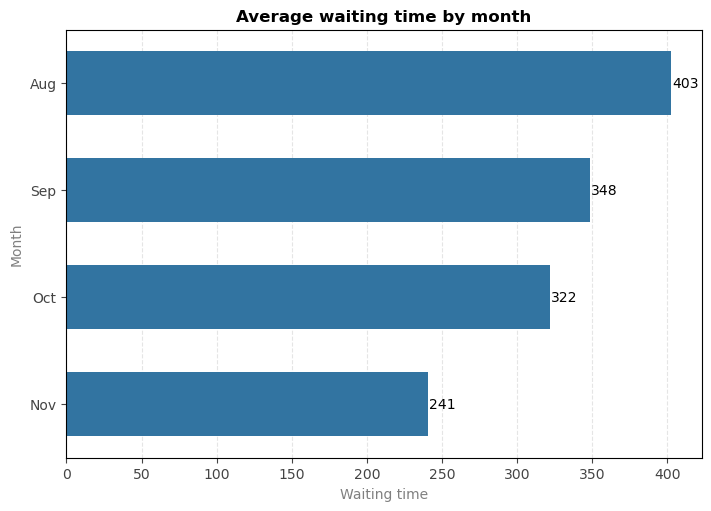

In [ ]:
tele_data_aht = tele_data.copy()
tele_data_aht['waiting_time'] = (tele_data_aht['total_call_duration'] - tele_data_aht['call_duration'])
table_waiting_time = tele_data_aht.groupby('month')['waiting_time'].mean().reset_index()
month_map = {
    8: 'Aug',
    9: 'Sep',
    10: 'Oct',
    11: 'Nov' 
}
table_waiting_time['month'] = table_waiting_time['month'].map(month_map)
fig = plt.figure(constrained_layout=True, figsize=(7,5));
ax = sns.barplot(
    data= table_waiting_time, 
    x = 'waiting_time', 
    y = 'month',
    width= 0.6
    )
ax.set_title('Average waiting time by month', fontdict = title)
ax.set_ylabel('Month', fontdict = subtitle)
ax.set_xlabel('Waiting time', fontdict = subtitle )
ax.tick_params(axis='both', labelsize=10, colors='#444444')
ax.xaxis.grid(True, linestyle='--', alpha=0.5, color='#cccccc')
ax.set_axisbelow(True)
for conteiner in ax.containers:
    ax.bar_label(conteiner, fmt = '%.0f', label_type = 'edge', padding = 1, fontsize = 10)
plt.show()

#### 2.5 Ranking agents lees efficents according whith:
- AHT (*Average Handle Time*)
- Number of calls

In [ ]:
# First add columns o as Internal_num become the interal True as 0 and False as 1 
tele_data['internal_num'] = tele_data['internal'].map({True:0, False:1})
tele_data.dropna(inplace = True)
ranking = tele_data.groupby('operator_id').agg(
    AHT = ('call_duration','sum'),
    number_call = ('internal','count')    
).reset_index()
# looking for average operator_id on the second semester from aug to nov  
total_AHT = ranking['AHT'].sum()
total_call = ranking['number_call'].sum()
ranking['AHT_pct'] = (ranking['AHT'] / total_AHT) * 100 
ranking['calls_pct'] = (ranking['number_call'] / total_call) * 100
# delete call not answear 
ranking = ranking[ranking['operator_id']!= 0]



In [ ]:
# Low-performing operators
ranking.sort_values(by =['AHT_pct','calls_pct'], ascending = True).head(10)

,operator_id,AHT,number_call,AHT_pct,calls_pct
16,883018.0,0,1,0.0,0.002068
93,891976.0,0,1,0.0,0.002068
248,905308.0,0,1,0.0,0.002068
254,905480.0,0,1,0.0,0.002068
382,914272.0,0,1,0.0,0.002068
387,914626.0,0,1,0.0,0.002068
457,919418.0,0,1,0.0,0.002068
529,924572.0,0,1,0.0,0.002068
571,928284.0,0,1,0.0,0.002068
618,932246.0,0,1,0.0,0.002068


In [ ]:
# High-performing operators 
ranking.sort_values(by =['AHT_pct','calls_pct'], ascending = False).head(10)

,operator_id,AHT,number_call,AHT_pct,calls_pct
29,885876.0,4363953,283,10.286690,0.585206
30,885890.0,3340790,253,7.874895,0.523170
552,925922.0,828782,73,1.953601,0.150954
958,952948.0,471369,95,1.111109,0.196447
204,901880.0,432093,299,1.018528,0.618292
369,913938.0,369657,148,0.871354,0.306044
13,882686.0,366417,224,0.863716,0.463202
59,890406.0,354294,214,0.835140,0.442524
58,890404.0,345312,227,0.813968,0.469406
57,890402.0,335179,217,0.790082,0.448727


### **3. Test statistical hypotheses**

In [ ]:
from statsmodels.stats.power import GofChisquarePower
from math import ceil
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

#### 3.1 significant difference in unanswered call according to the plan 

In [ ]:
## ANOVA 
# Plan A,B, C diferents mean on missing calls 
# Merge data to have the information of the user and the calls
telecom_full = pd.merge(tele_cx,tele_data, on ='user_id', how = 'inner' )

telecom_full['missed'] = telecom_full['is_missed_call'].astype(int)
user_level = (telecom_full.groupby(['user_id','tariff_plan'])
    .agg(
        total_calls=('calls_count','sum'),
        missed_calls=('missed','sum')
    )
    .reset_index())
user_level
user_level['missed_rate'] = (
    user_level['missed_calls'] / user_level['total_calls']
)
# Split groups 
group_A = user_level[user_level['tariff_plan']=='A']['missed_rate']
group_B = user_level[user_level['tariff_plan']=='B']['missed_rate']
group_C = user_level[user_level['tariff_plan']=='C']['missed_rate']
# anova test 
stat, pval = f_oneway(group_A, group_B, group_C)
print("p-value:{:.4f}".format(pval))
if pval > 0.05:
    print('it is a null hypothesis; there is no significant difference')
else:    print('We reject the null hypothesis; there is a significant difference')

p-value:0.0415
We reject the null hypothesis; there is a significant difference


In [ ]:
tukey = pairwise_tukeyhsd(
    endog=user_level['missed_rate'],
    groups=user_level['tariff_plan'],
    alpha=0.05
)
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     A      B   0.0863 0.0366  0.0042 0.1684   True
     A      C   0.0773 0.0573 -0.0019 0.1564  False
     B      C  -0.0091   0.91 -0.0606 0.0425  False
---------------------------------------------------


#### 3.2 The average call duration for inbound calls is equal to outbound calls.

In [ ]:
outbound_calls = telecom_full[telecom_full['direction']=='out']['call_duration']
inbound_calls = telecom_full[telecom_full['direction']=='in']['call_duration']

from scipy.stats import ttest_ind
stat, pval = ttest_ind(outbound_calls, inbound_calls)
print(pval)
if pval > 0.05:
    print('it is a null hypothesis; there is no significant difference')
else:    print('We reject the null hypothesis; there is a significant difference')

4.2613921568307024e-76
We reject the null hypothesis; there is a significant difference


#### 3.3 The average waiting time is the same across all months.

In [ ]:
telecom_full['waiting_time'] = telecom_full['total_call_duration'] - telecom_full['call_duration']
waiting_time = telecom_full.pivot_table(
    index  = 'month', 
    columns = 'direction',
    values = 'waiting_time',
    aggfunc = 'mean'
).reset_index()
in_call = waiting_time['in']
out_call = waiting_time['out']
from scipy.stats import ttest_rel
t_stat, p_value = ttest_rel(in_call, out_call)
print(f'P-value: {p_value:.4f}')
if p_value > 0.05:
    print('it is a null hypothesis; there is no significant difference')
else:    print('We reject the null hypothesis; there is a significant difference')


P-value: 0.0244
We reject the null hypothesis; there is a significant difference


In the analysis, we evaluate both the service received by the customer and the efficiency of the operators.
The service information is assessed based on three categories: whether the customer received assistance on the first call, whether they did not receive assistance at all, and whether they called more than once on the same day. The analysis was conducted by month; customers were most likely to be attended on the first call, which indicates efficiency in answering incoming calls, followed by those who did not receive service. It is not common for users to call more than once on the same day.

Regarding wait times, the highest averages were recorded in August and September, with 402 and 348 seconds respectively. October and November showed improvement, with averages of 321 and 240 seconds. Comparing the wait times in October and November with the number of users attended on the first call — 4,658 and 5,233 respectively — confirms a clear improvement in service quality.
Analyzing operator efficiency using two KPIs — number of calls handled and Average Handle Time (AHT) — the least efficient operators are identified by a high AHT. Among the low-performance operators, some handled only one call with a low AHT, which requires further investigation into why they completed so few calls. Additionally, other operators handled more calls but took considerably longer to assist each user.

## **Statistical Hypotheses conclution**

A one-way ANOVA was used to evaluate differences in unanswered calls according to the subscription plan. A statistically significant difference was found between Plan A and Plan C, and between Plan B and Plan C, where Plan C showed the greatest difference in user behavior.
Additionally, two hypotheses were tested: whether the call duration of inbound calls is equal to that of outbound calls, and whether the average wait time is the same across all months. Both hypotheses were rejected, confirming statistically significant differences in each case.

### *Conclusion*

The analysis of the CallMeMaybe call center reveals both strengths and areas for improvement. On the service side, the majority of customers were successfully attended on their first call, reflecting a generally efficient response system. Furthermore, a positive trend was observed over time, with wait times decreasing from August through November, and first-call attendance increasing during the same period, suggesting ongoing operational improvements.
On the efficiency side, operator performance varied considerably. Some operators handled very few calls, while others showed high AHT values, indicating that targeted interventions, such as additional training or workload redistribution.
Finally, the statistical analysis confirmed that subscription plan type significantly influences the rate of unanswered calls, and that meaningful differences exist in both call duration and wait times across months. These findings suggest that service strategies should be tailored by plan type, and that continued monitoring of monthly trends is essential to sustaining the improvements observed.
